# Silhouette Score

Silhouette measures how well a point fits into its cluster compared to other clusters.

For each point:
- **a** — average distance to points in the same cluster
- **b** — smallest average distance to points in other clusters

Silhouette value:
$$
s = \frac{b - a}{\max(a, b)}
$$

Range: **-1 to 1**

- Close to **1** → well clustered
- Close to **0** → overlapping clusters
- Negative → likely misclustered


# Setup

In [4]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mlpeople.models.clustering.metrics import silhouette_from_scratch
from mlpeople.models.clustering.visualization import plot_silhouette, plot_clusters_and_silhouette

iris_df = pd.read_csv("./data/iris.csv")
mall_df = pd.read_csv("./data/Mall_Customers.csv", index_col="CustomerID")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1. Iris - correct K (baseline)

Silhouette (K=3): 0.5599188310298457


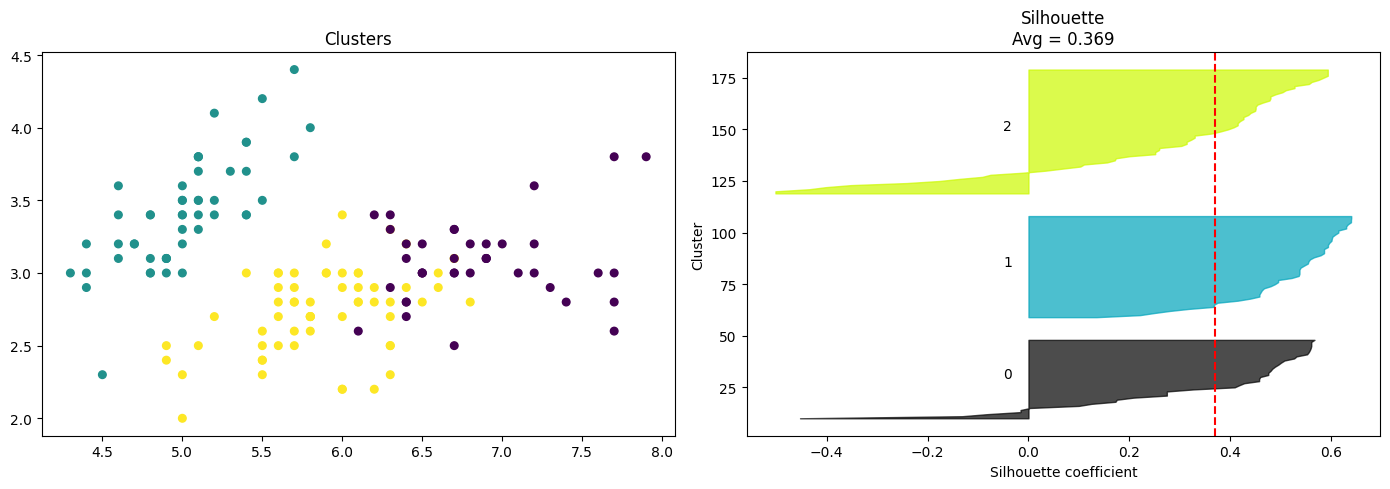

In [26]:
from sklearn.cluster import KMeans

X = iris_df.drop(columns=["species"]).values

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)

sil_vals, sil_avg = silhouette_from_scratch(X, labels)
print("Silhouette (K=3):", sil_avg)

plot_clusters_and_silhouette(X[:, :2], labels)

# 2. Iris - wrong K

K=4, silhouette=0.511


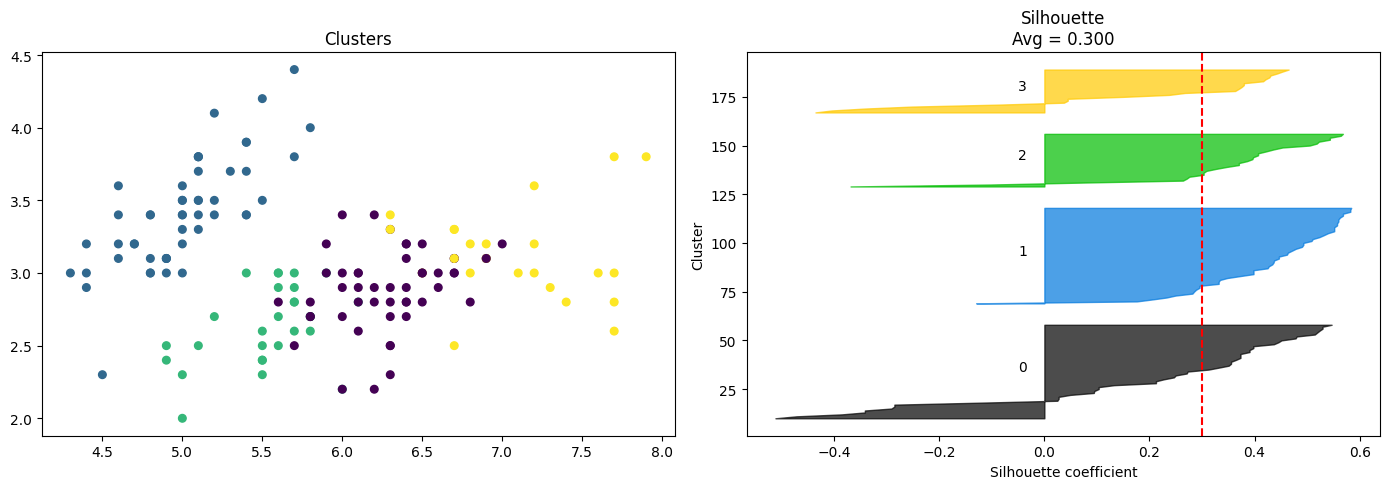

K=5, silhouette=0.507


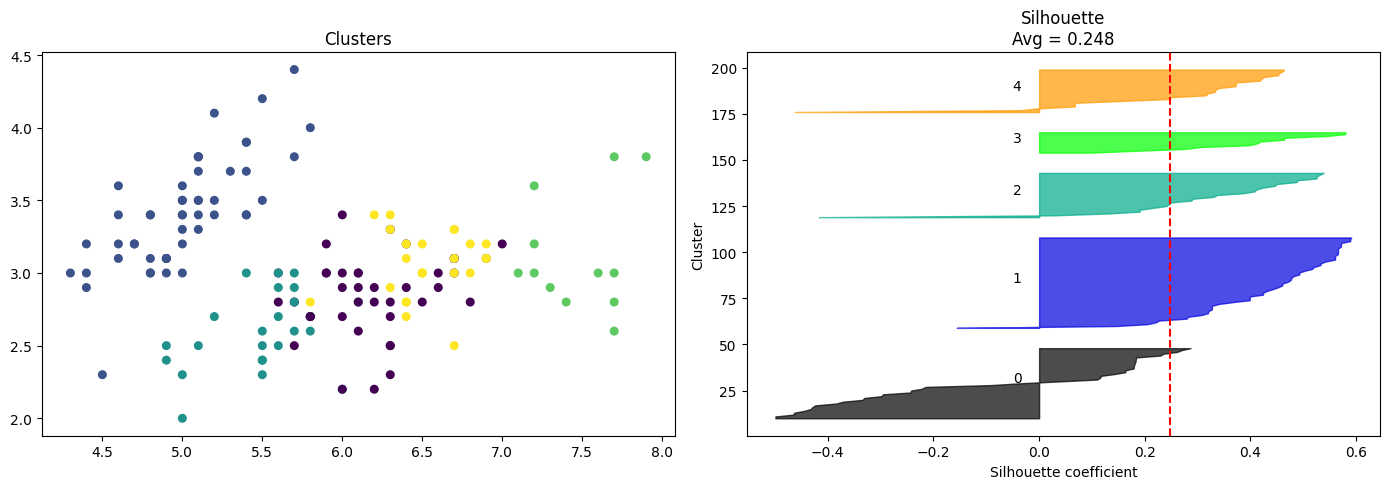

K=6, silhouette=0.389


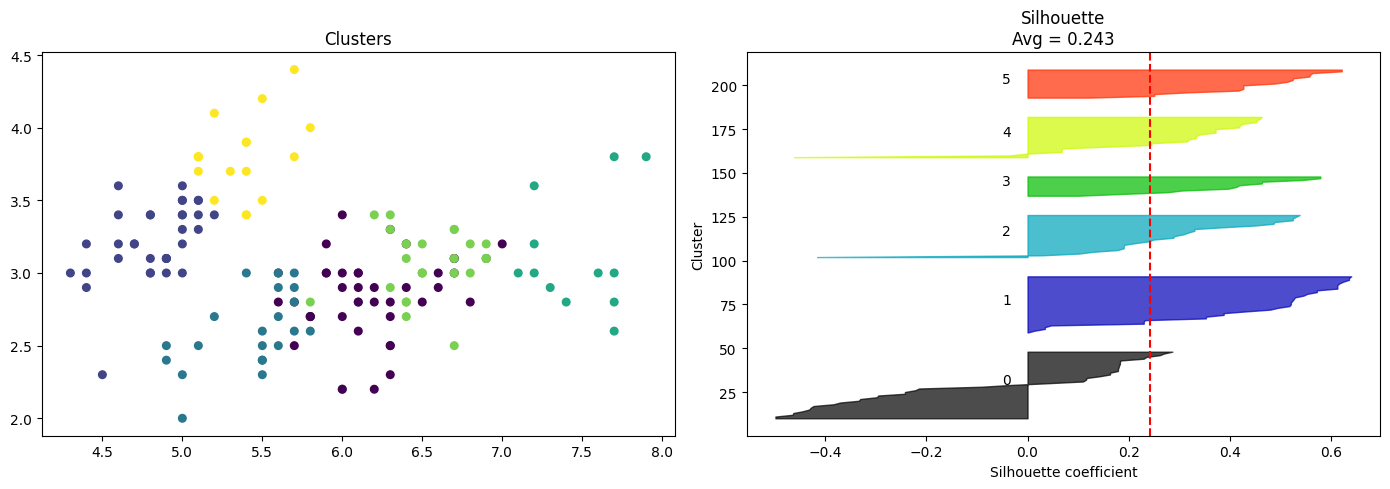

In [8]:
for k in [4, 5, 6]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)

    _, sil_avg = silhouette_from_scratch(X, labels)
    print(f"K={k}, silhouette={sil_avg:.3f}")

    plot_clusters_and_silhouette(X[:, :2], labels)

# 3. Mall - reasonable segmentation

Mall silhouette: 0.5653234146367464


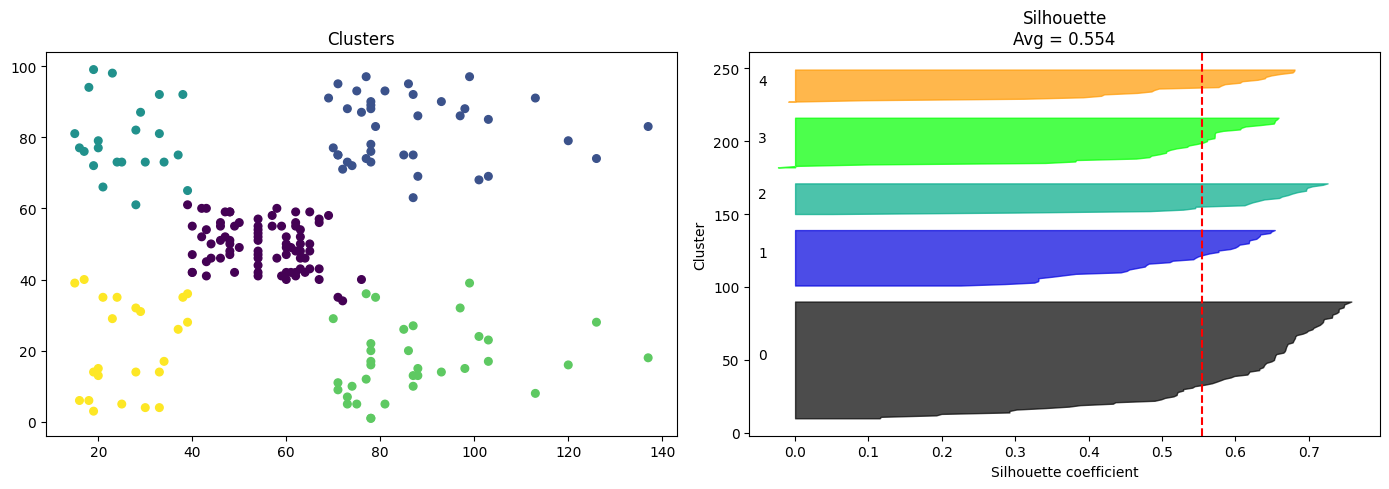

In [9]:
X = mall_df[["Annual Income (k$)", "Spending Score (1-100)"]].values

kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X)

sil_vals, sil_avg = silhouette_from_scratch(X, labels)
print("Mall silhouette:", sil_avg)

plot_clusters_and_silhouette(X, labels)

# 4. Mall - add noisy features

With noise silhouette: 0.31562087675578426


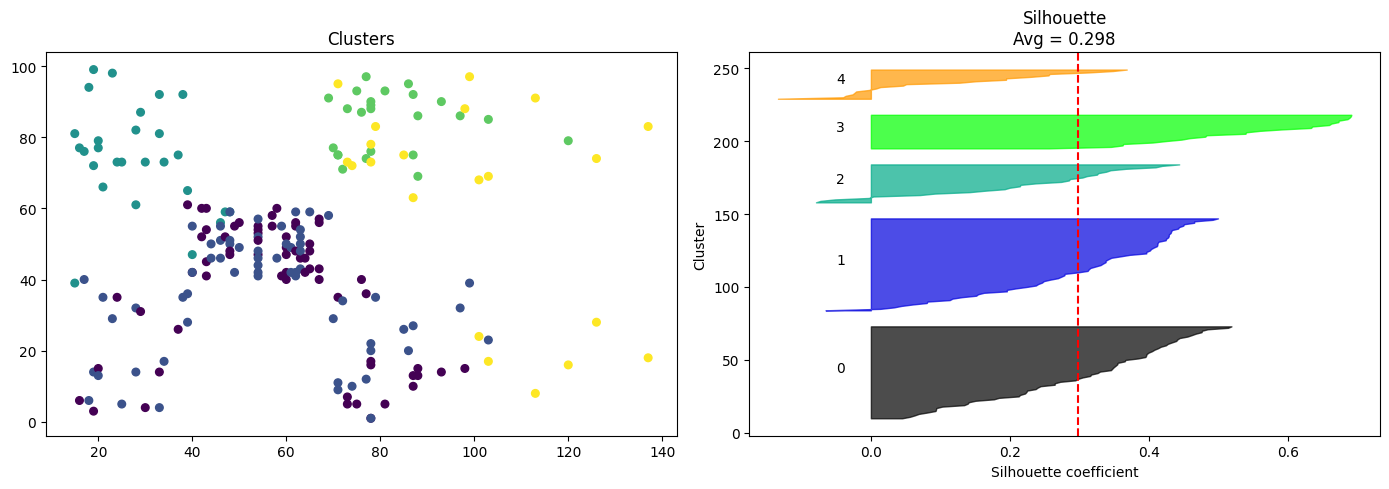

In [19]:
np.random.seed(42)
noise = np.random.rand(len(X), 1) * 100 # multiply by 100 to make the same scale

X_noisy = np.hstack([X, noise])

kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X_noisy)

_, sil_avg = silhouette_from_scratch(X_noisy, labels)
print("With noise silhouette:", sil_avg)

plot_clusters_and_silhouette(X_noisy, labels)

# 5. Mall - add outliers

With outliers silhouette: 0.5119346376737759


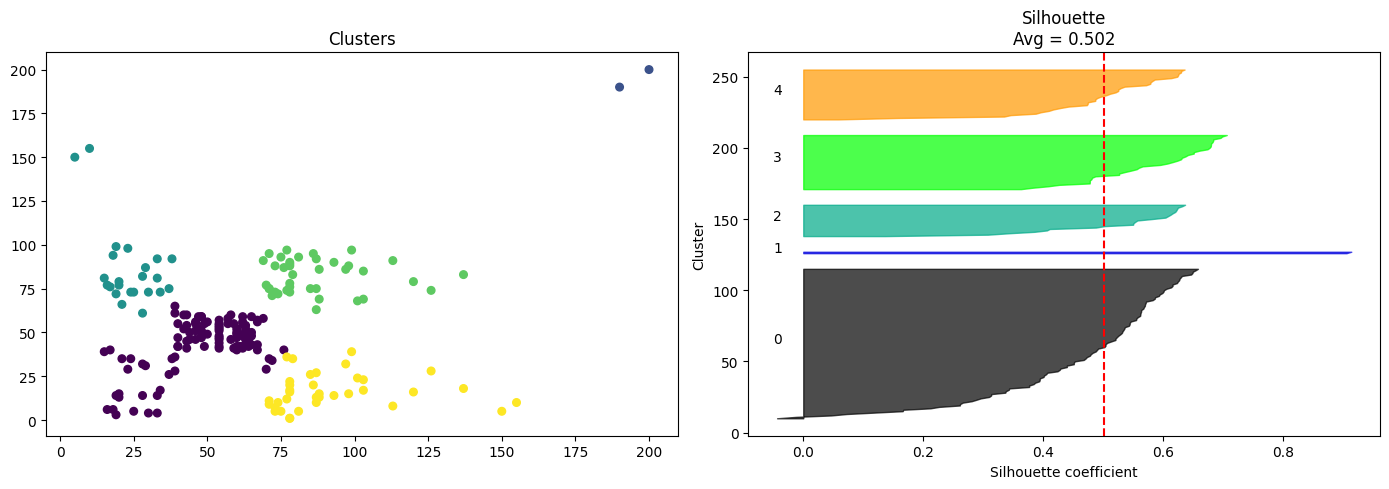

In [22]:
outliers = np.array([[150, 5], [5, 150], [200, 200], [155, 10], [10, 155], [190, 190]])
X_out = np.vstack([X, outliers])

kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X_out)

_, sil_avg = silhouette_from_scratch(X_out, labels)
print("With outliers silhouette:", sil_avg)

plot_clusters_and_silhouette(X_out, labels)

# 6. Failure case - moons (K-Means bad)

Moons + KMeans silhouette: 0.49146740943452516


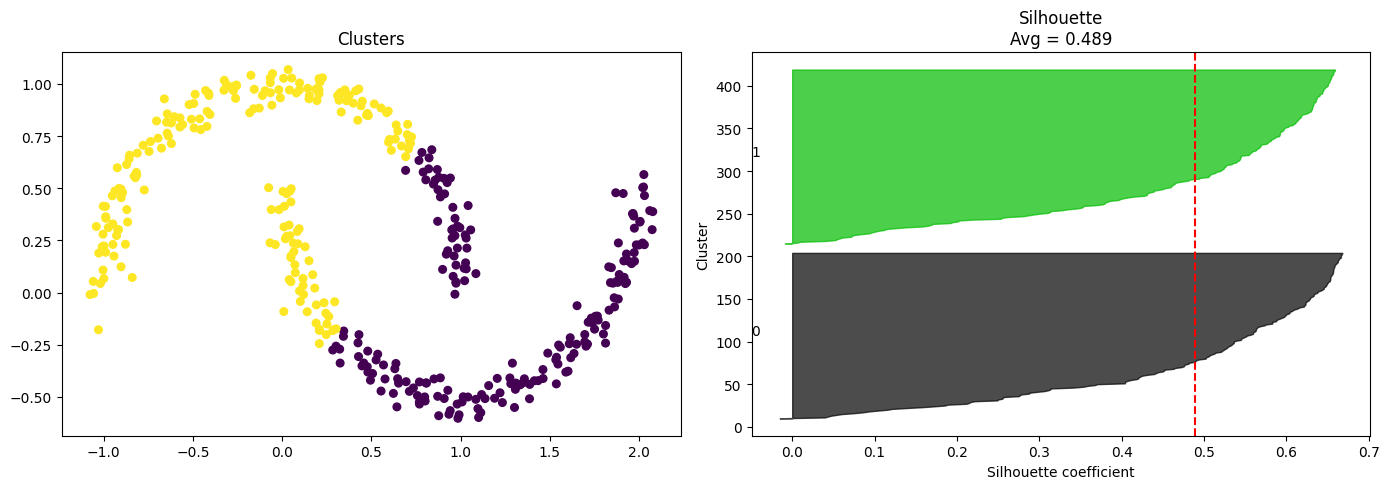

In [23]:
from sklearn.datasets import make_moons

X_moons, _ = make_moons(n_samples=400, noise=0.05, random_state=42)

kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X_moons)

_, sil_avg = silhouette_from_scratch(X_moons, labels)
print("Moons + KMeans silhouette:", sil_avg)

plot_clusters_and_silhouette(X_moons, labels)

# 7. Moons - DBSCAN fixes it

Moons + DBSCAN silhouette: 0.33052887525276586


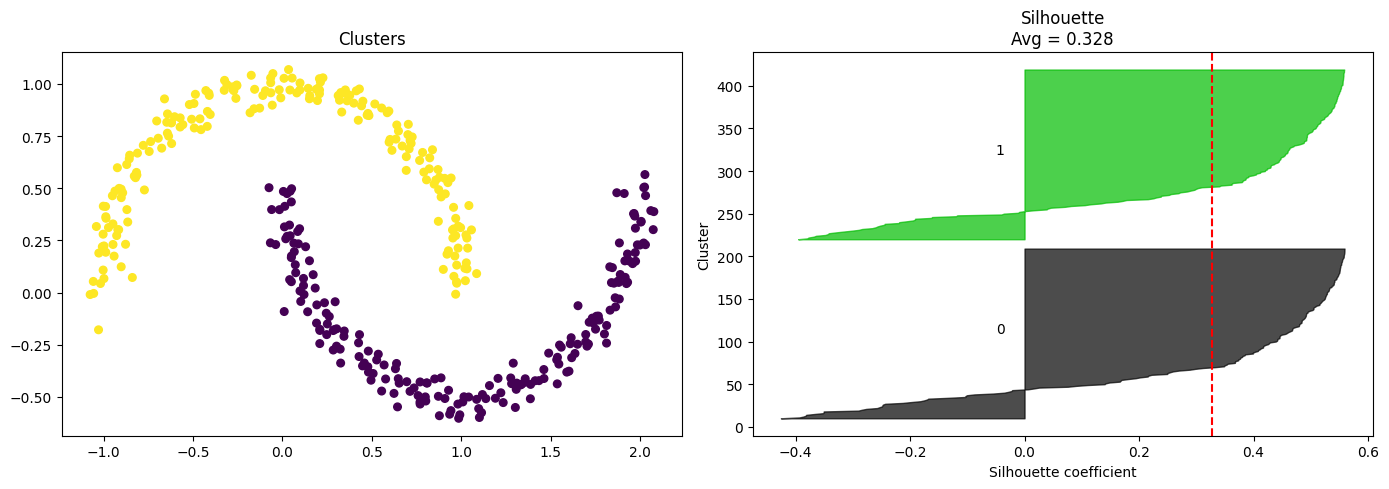

In [24]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.2, min_samples=5)
labels = db.fit_predict(X_moons)

_, sil_avg = silhouette_from_scratch(X_moons, labels)
print("Moons + DBSCAN silhouette:", sil_avg)

plot_clusters_and_silhouette(X_moons, labels)

## Important limitation of Silhouette

Silhouette favors compact, spherical, well-separated clusters.

On non-convex shapes like moons:
- K-Means gives higher silhouette but wrong clustering
- DBSCAN gives lower silhouette but correct clustering

Silhouette measures Euclidean compactness, not true cluster structure.

# 8. Silhouette vs K curve

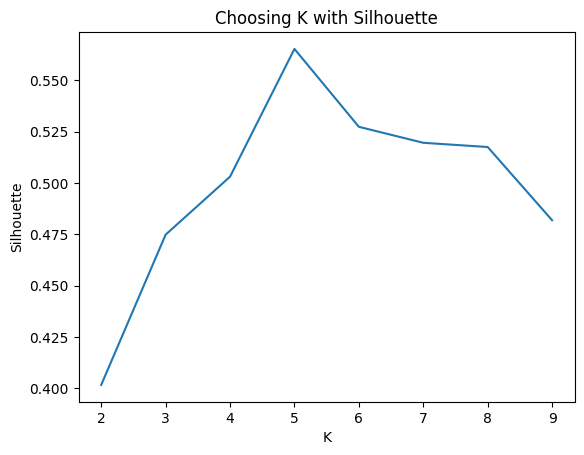

In [25]:
scores = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)

    _, sil_avg = silhouette_from_scratch(X, labels)
    scores.append(sil_avg)

plt.plot(range(2, 10), scores)
plt.xlabel("K")
plt.ylabel("Silhouette")
plt.title("Choosing K with Silhouette")
plt.show()